In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits import mplot3d


In [2]:
def model(x, w, b):
    y = w*x + b
    return y

In [3]:
def compute_cost(x, y, w, b): 
    # J function
    e = y - model(x, w, b) # (w*x+b)
    m = x.shape[0]
    total_cost = (1/(2* m)) * sum(e**2)
    return total_cost


In [4]:
# data
x_train = np.array([1.0, 1.7, 2.0, 2.5, 3.0, 3.2])
y_train = np.array([250, 300, 480,  430,   630, 730,])

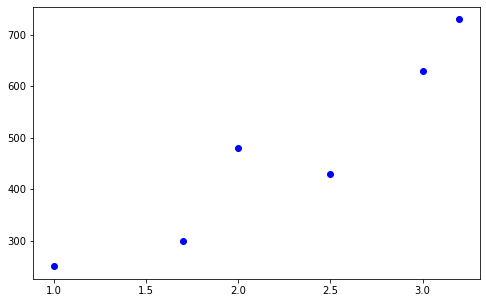

In [5]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(x_train, y_train, 'bo');

In [6]:
w_cand = np.arange(-100, 500, 10)
b_candid = np.arange(-300, 300, 10)
W, B = np.meshgrid(w_cand, b_candid)
gshape = B.shape

costs = np.zeros((gshape))
for i in range(gshape[0]):
    for j in range(gshape[1]):
        costs[i, j] = compute_cost(x_train, y_train, W[i, j], B[i, j])



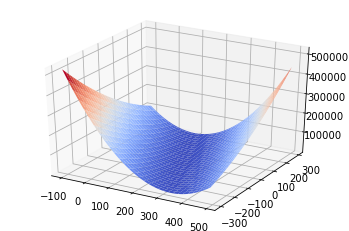

In [7]:
# Plot the surface.
fig_s, ax_s = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax_s.plot_surface(W, B, costs, cmap=cm.coolwarm)
plt.show()

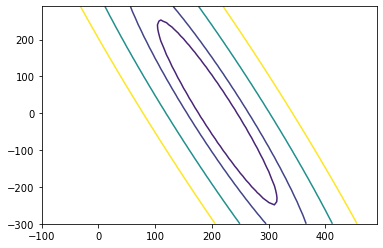

In [8]:
fig_c, ax_c = plt.subplots()
contours = [0.1,50,1000,5000,10000,25000,50000]
ax_c.contour(W, B, costs, contours) 


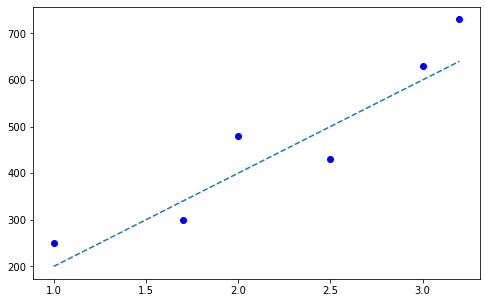

In [9]:
y_pred = model(x_train, 200, 0)
ax.plot(x_train, y_pred, '--');
fig

In [10]:
def compute_gradient(x, y, w, b): 
    # Number of training examples
    m = x.shape[0] 
    dw = (1/m) * (model(x, w, b)- y) * x 
    db = (1/m) * (model(x, w, b)- y)
    dw = sum(dw)
    db = sum(db)
    return dw, db

In [11]:
from copy import deepcopy
def gradient_descent(x, y, w_in = 0, b_in = 0, alpha = 1, num_iters = 100):
    
    w = deepcopy(w_in)
    b = deepcopy(b_in)
    p_history = [(w, b)]
    cost_history  = [compute_cost(x, y, w, b)] # J
    
    for i in range(num_iters):
        dw, db = compute_gradient(x, y, w, b)
        w = w - alpha * dw
        b = b - alpha * db
        p_history.append((w, b))
        cost_history.append(compute_cost(x, y, w, b))
        if i%100 == 0:
            print(f"Iteration {i:4}: Cost {cost_history[-1]:0.2e} ",
                  f"dj_dw: {dw: 0.3e}, dj_db: {db: 0.3e}  ",
                  f"w: {w: 0.3e}, b:{b: 0.5e}")

    return w, b, p_history, cost_history


In [12]:
# initialize parameters
w_init = 0
b_init = 0
# some gradient descent settings
iterations = 500
tmp_alpha = 1.0e-1
# run gradient descent
w_final, b_final, p_history, cost_history = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, iterations)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")


Iteration    0: Cost 1.73e+04  dj_dw: -1.170e+03, dj_db: -4.700e+02   w:  1.170e+02, b: 4.70000e+01
Iteration  100: Cost 1.78e+03  dj_dw: -1.056e+00, dj_db:  2.590e+00   w:  1.976e+02, b: 3.12951e+01
Iteration  200: Cost 1.74e+03  dj_dw: -4.326e-01, dj_db:  1.060e+00   w:  2.045e+02, b: 1.42445e+01
Iteration  300: Cost 1.74e+03  dj_dw: -1.771e-01, dj_db:  4.342e-01   w:  2.074e+02, b: 7.26319e+00
Iteration  400: Cost 1.74e+03  dj_dw: -7.252e-02, dj_db:  1.778e-01   w:  2.086e+02, b: 4.40468e+00
(w,b) found by gradient descent: (209.0289,  3.2415)


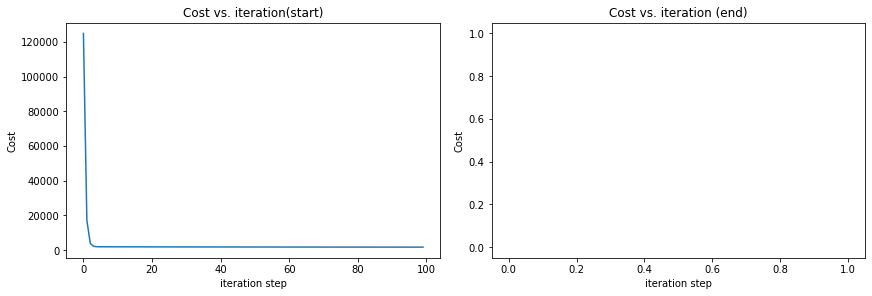

In [13]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(cost_history[:100])
ax2.plot(1000 + np.arange(len(cost_history[1000:])), cost_history[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step') 
plt.show()